## Inicialización

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## EDA

In [3]:
LABELS_PATH = "/datasets/faces/labels.csv"
IMAGES_DIR = "/datasets/faces/final_files/"

In [4]:
labels = pd.read_csv(LABELS_PATH)
display(labels.head())
print("Shape:", labels.shape)
print("\nColumnas:", list(labels.columns))


age_col_candidates = [c for c in labels.columns if c.lower() in ["real_age", "age", "target", "label"]]
age_col = age_col_candidates[0] if age_col_candidates else None

file_col_candidates = [c for c in labels.columns if c.lower() in ["file_name", "filename", "file", "img", "image", "path"]]
file_col = file_col_candidates[0] if file_col_candidates else None

labels = labels.dropna(subset=[age_col, file_col]).copy()
labels[age_col] = labels[age_col].astype(int)
labels[file_col] = labels[file_col].astype(str)

print("\nDespués de limpiar NAs:")
print("Shape:", labels.shape)

def resolve_image_path(fname: str) -> str:
    
    base = os.path.basename(fname)
    p1 = os.path.join(IMAGES_DIR, fname)
    p2 = os.path.join(IMAGES_DIR, base)
    return p1 if os.path.exists(p1) else p2

labels["img_path"] = labels[file_col].apply(resolve_image_path)
missing = (~labels["img_path"].apply(os.path.exists)).sum()
print(f"\nImágenes faltantes (no encontradas): {missing}")

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


Shape: (7591, 2)

Columnas: ['file_name', 'real_age']

Después de limpiar NAs:
Shape: (7591, 2)

Imágenes faltantes (no encontradas): 0



Resumen edad:
count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64


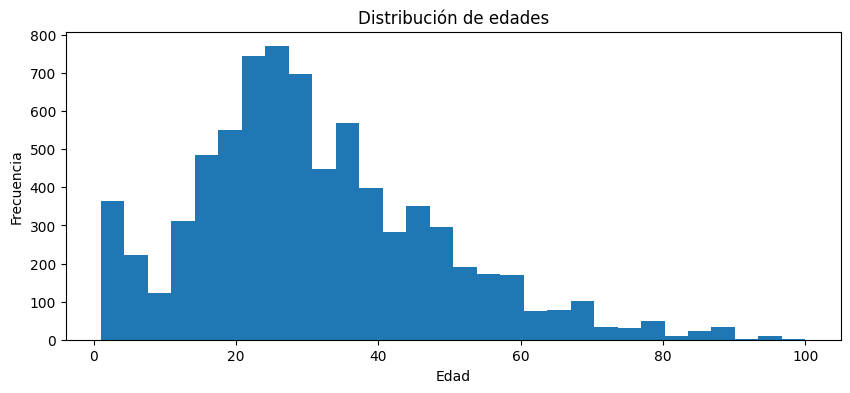

In [5]:
print("\nResumen edad:")
print(labels[age_col].describe())

plt.figure(figsize=(10, 4))
plt.hist(labels[age_col], bins=30)
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


In [6]:
n_show = 15
ages_sorted = labels[age_col].sort_values().values

In [7]:
quantiles = [i/(n_show-1) if n_show > 1 else 0.5 for i in range(n_show)]
selected_ages = []
for q in quantiles:
    a = int(pd.Series(ages_sorted).quantile(q))
    selected_ages.append(a)
selected_ages = sorted(list(dict.fromkeys(selected_ages)))

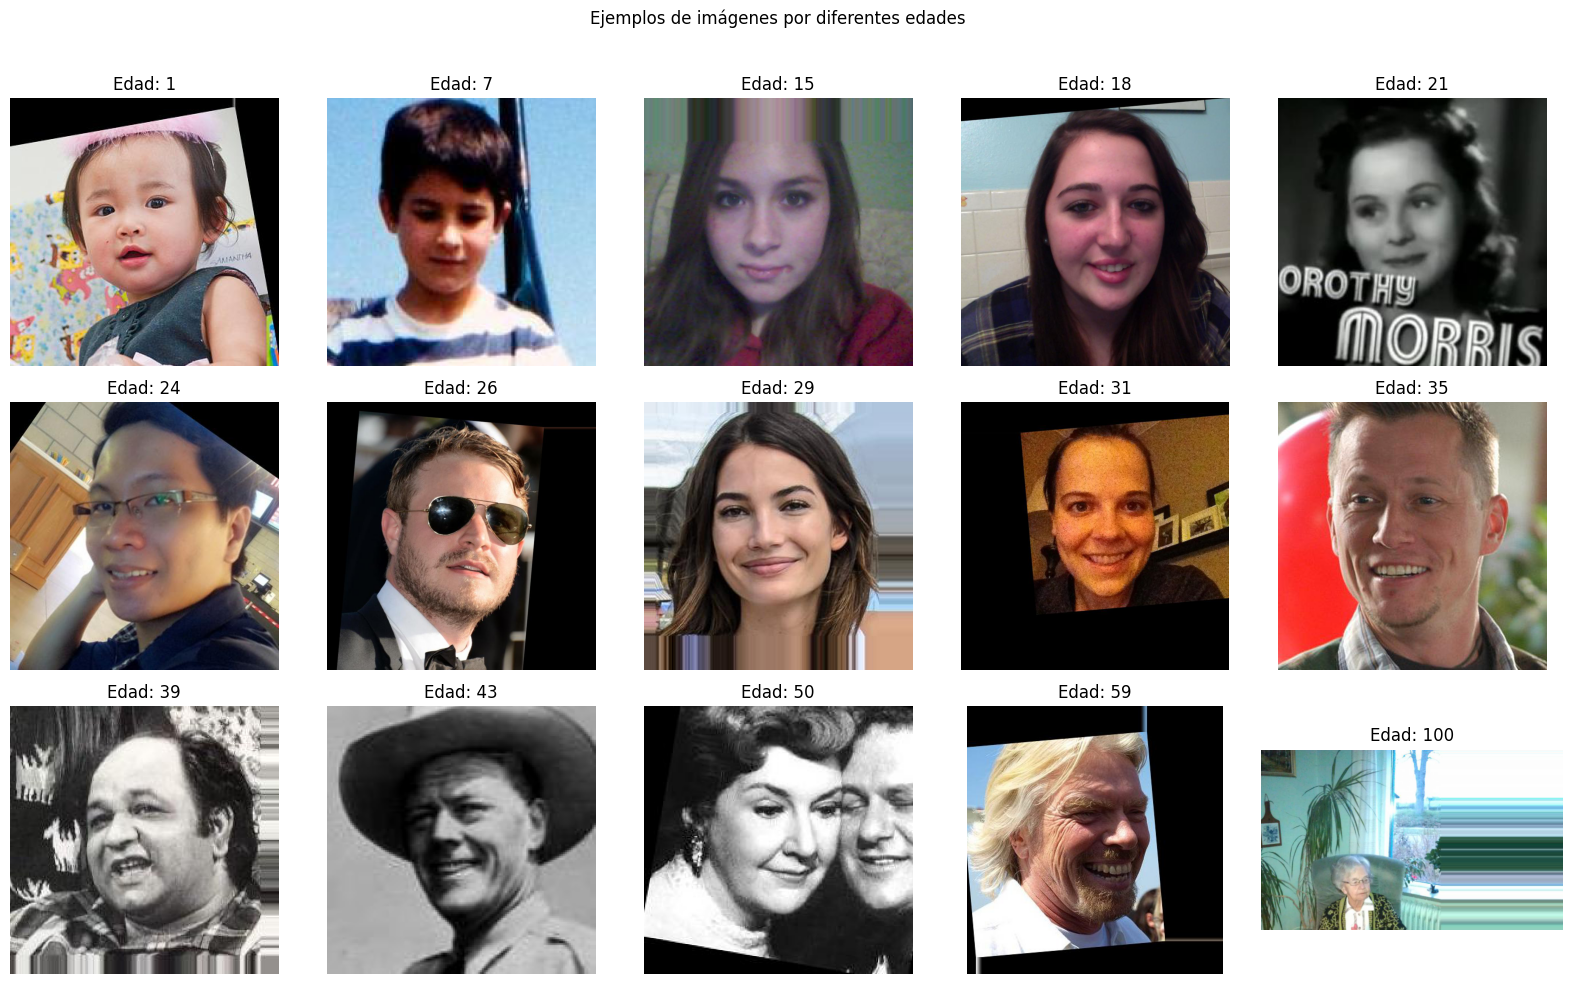

In [8]:
fig_cols = 5
fig_rows = (len(selected_ages) + fig_cols - 1) // fig_cols
plt.figure(figsize=(fig_cols * 3.2, fig_rows * 3.2))

plot_idx = 1
shown = 0

for a in selected_ages:
    subset = labels[labels[age_col] == a]
    if subset.empty:
        continue

    
    row = subset.sample(1, random_state=42).iloc[0]
    img_path = row["img_path"]

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path).convert("RGB")

    ax = plt.subplot(fig_rows, fig_cols, plot_idx)
    ax.imshow(img)
    ax.set_title(f"Edad: {a}")
    ax.axis("off")

    plot_idx += 1
    shown += 1

    if shown >= 15:
        break

plt.suptitle("Ejemplos de imágenes por diferentes edades", y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones

El conjunto de datos contiene 7591 imagenes faciales con edades que van de 1 a 100 anios. La distribucion de edades no es uniforme y presenta una fuerte concentracion entre adultos jovenes, con una edad media de 31 anios.

La inspeccion visual revela alta variabilidad en terminos de iluminacion, calidad y contexto de las fotografias.

Estas caracteristicas justifican el uso de modelos preentrenados como ResNet y el tratamiento del problema como una tarea de regresion. Los resultdos del modelo deben interpretarse cosiderando el contexto del negocio, ya que errores cerca del umbral legal de edad pueden tener consecuencias mas graves que errores en otros rangos.

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [1]:
from tensorflow.keras.applications.resnet import preprocess_input

import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam



In [2]:
def load_train(path):
    labels = pd.read_csv(path + 'labels.csv')
    
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """
    
    train_datagen= ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split = 0.25,
            horizontal_flip = True,
            rotation_range = 10,
            width_shift_range = 0.10,
            height_shift_range = 0.10,
            zoom_range = 0.10
        )
    train_gen_flow= train_datagen.flow_from_dataframe(
            dataframe = labels,
            directory = path + 'final_files/',
            x_col = 'file_name',
            y_col = 'real_age',
            target_size = (224,224),
            batch_size = 16,
            class_mode = 'raw',
            subset = 'training',
            seed = 42,
            shuffle=True
        )
     
        
    return train_gen_flow

In [3]:
def load_test(path):
    
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """
    labels = pd.read_csv(path + 'labels.csv')
    
    test_datagen= ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split = 0.25
    )
    
    test_gen_flow= test_datagen.flow_from_dataframe(
            dataframe = labels,
            directory = path + 'final_files/',
            x_col = 'file_name',
            y_col = 'real_age',
            target_size = (224,224),
            batch_size = 16,
            class_mode = 'raw',
            subset = 'validation',
            seed = 42,
            shuffle=False
        )
    
    

    return test_gen_flow

In [4]:
def create_model(input_shape):
    
    """
    Define el modelo
    """
    backbone = ResNet50(
        weights='imagenet',
        input_shape=input_shape,
        include_top=False
    )

    backbone.trainable = True
    for layer in backbone.layers[:-20]:
        layer.trainable= False

    model=Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    

    return model

In [5]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Entrena el modelo dados los parámetros
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(
        train_data,
        validation_data = test_data,
        epochs = epochs,
        steps_per_epoch = steps_per_epoch,
        validation_steps = validation_steps,
        verbose = 2
    )

    return model

In [ ]:
input_shape = (224, 224, 3)

train_data = load_train("/datasets/faces/")
test_data = load_test("/datasets/faces/")

model = create_model(input_shape)
model = train_model(model,train_data, test_data, epochs=3)

Found 5694 validated image filenames.
Found 1897 validated image filenames.


2026-01-27 06:00:57.831308: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


94781440/94765736 [==============================] - 1s 0us/step
Epoch 1/3


## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [ ]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')
        f.write("""
        input_shape = (224,224,3)
        
        train_data= load_train('/datasets/train/')
        test_data = load_test('/datasets/test/')

        model = create_model(input_shape)
        model = train_model(model, train_data, test_data, epochs=3)
        """)

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

## Conclusiones

# Lista de control

- [ ]  El Notebook estaba abierto 
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución
- [ ]  Se realizó el análisis exploratorio de datos 
- [ ]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [ ]  El valor EAM del modelo no es superior a 8 
- [ ]  El código de entrenamiento del modelo se copió en el notebook final 
- [ ]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [ ] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo